In [1]:
import xarray as xr 
import pandas as pd 
import numpy as np 
import os 
import yaml
from data_handling import * 
import sys 
sys.path.append('/jet/home/cwilson4/PEBSI/')
from shop.plotting.plotting_fxns import *
import geopandas as gpd
import rioxarray

translate_names = {}
for glacier, vals in translate_rgi.items():
    translate_names[vals['6']] = glacier

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

In [2]:
base_fp = '/ocean/projects/ees260009p/cwilson4/Output/'
rgi_fp = base_fp + '../RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp'

ds_base = xr.open_zarr(base_fp + 'extremes/base_0/output.zarr')
ds_nofires = xr.open_zarr(base_fp + 'extremes/no_fires_0/output.zarr')
ds_no_heatwaves = xr.open_zarr(base_fp + 'extremes/no_heatwaves_0/output.zarr')
ds_no_either = xr.open_zarr(base_fp + 'extremes/no_either_0/output.zarr')

with open(base_fp + 'extremes/base_0/config.yaml') as f:
    configs = yaml.safe_load(f) 

sites = configs['sites']
rgiids = configs['rgi_ids']

ds_dict = {'Base': ds_base, 'No fires': ds_nofires, 'No heatwaves': ds_no_heatwaves, 'Neither': ds_no_either}

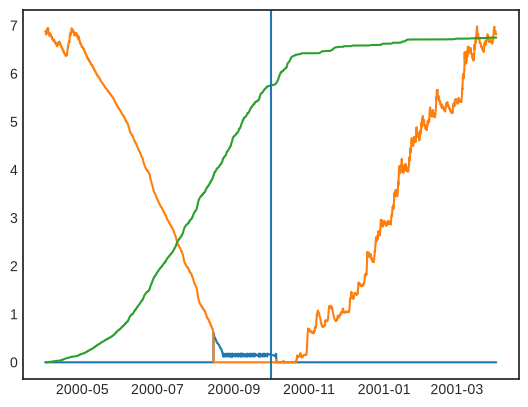

In [ ]:
ds_base = xr.open_zarr(base_fp + 'extremes/base_2/output.zarr')

glacier, site = 'wolverine', 'A'
idx = np.where((np.array(rgiids) == translate_rgi[glacier]['6']) & (np.array(sites) == site))[0]
ds = ds_base.sel(point=idx, time=slice('2000-04-01','2001-04-01')).squeeze()
# visualize_layers_fast(ds, pd.date_range('2001-04-01','2002-09-01'), ['layergrainsize'])
plt.plot(ds.time, ds.firndepth)
plt.plot(ds.time, ds.snowdepth)
plt.plot(ds.time, ds.melt.cumsum())
plt.axvline(pd.to_datetime('2000-10-01'))


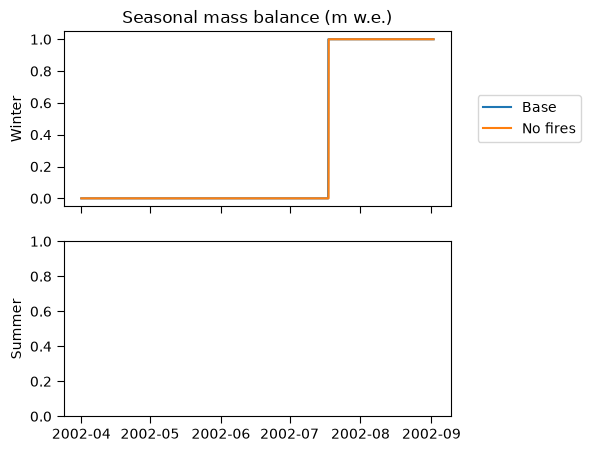

In [14]:
glacier, site = 'wolverine', 'A'
idx = np.where((np.array(rgiids) == translate_rgi[glacier]['6']) & (np.array(sites) == site))[0]

fig, (ax0, ax1) = plt.subplots(2, sharex=True, figsize=(5, 5))
for i, (ds, label, color) in enumerate(zip([ds_no_heatwaves, ds_nofires], ['Base','No fires'], ['k','r'])): #
    ds_pt = ds.sel(point=idx, layer=0).squeeze()
    # ds_pt = ds_pt.where(ds_pt.layertype == 0).albedo.resample(time='YS-MAY').min()
    ds_pt = ds_pt.sel(time=slice('2002-04-01','2002-09-01'))
    ax0.plot(ds_pt.time, ds_pt.layertype,label=label)

    # mb = MassBalance(glacier, site)
    # mb.get_model_mb(ds_pt)

    # idx_summer = mb.idx_summer 
    # idx_winter = mb.idx_winter
    # ends = mb.period_ends
    # mod = np.array(mb.mod)

    # ls = '--' if label == 'Base' else '-'
    # ax1.plot(ends[idx_summer], mod[idx_summer], marker='.', color=color, linestyle=ls)
    # ax0.plot(ends[idx_winter], mod[idx_winter], marker='.', label=label, color=color, linestyle=ls)

for ax in [ax0, ax1]:
    ax.tick_params(length=5)
ax1.set_ylabel('Summer')
ax0.set_ylabel('Winter')
ax0.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
ax0.set_title('Seasonal mass balance (m w.e.)')
# ax1.set_xticks(pd.date_range('2000-01-01','2010-01-01',freq='2YS'))
plt.show()

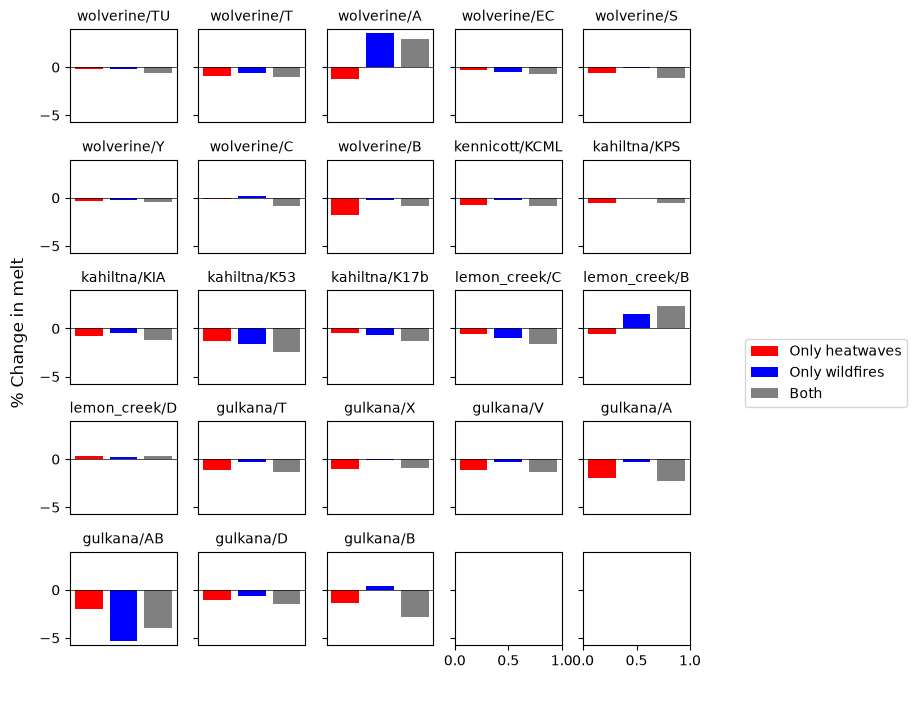

In [4]:
comparison_direction = 'with'
var_compare = 'melt'

if comparison_direction == 'with':
    base_balance = ds_no_either[var_compare].sum(dim='time')
    list_ds = [ds_nofires, ds_no_heatwaves, ds_base] 
    labels = ['Only heatwaves', 'Only wildfires', 'Both']
elif comparison_direction == 'without':
    base_balance = ds_base[var_compare].sum(dim='time')
    list_ds = [ds_nofires, ds_no_heatwaves, ds_no_either]
    labels = ['No wildfires', 'No heatwaves', 'Neither']

fig, axes = plt.subplots(5, 5, figsize=(8, 8), gridspec_kw={'hspace': 0.4}, sharey=True)
axes = axes.flatten()

secondary = fig.add_axes([1.02, 0.05, 0.1, 0.8])

by_rgi = {}
for j, (point, rgiid, site) in enumerate(zip(ds_base.point, rgiids, sites)):
    glacier = translate_names[rgiid]

    if rgiid not in by_rgi:
        by_rgi[rgiid] = {}

    site_base_balance = base_balance.sel(point=point).values
    # print(site, site_base_balance)

    for i, (ds, label, color) in enumerate(zip(list_ds, labels, ['r','b','gray'])):
        # annual_mb = ds_pt.mass_balance.resample(time='YS-OCT').sum()
        net_balance = ds.sel(point=point)[var_compare].sum()

        axes[j].bar(i, (site_base_balance - net_balance.values), facecolor=color) #  / site_base_balance

        if label not in by_rgi[rgiid]:
            by_rgi[rgiid][label] = []
        by_rgi[rgiid][label].append(site_base_balance - net_balance.values)

        if j == 0:
            secondary.bar(np.nan, np.nan, label=label, facecolor=color)

    axes[j].set_title(f'{glacier}/{site}', fontsize=10)
    axes[j].set_xticks([])
    axes[j].axhline(0, linewidth=0.5, c='k')
    
secondary.axis('off')
secondary.legend(loc='center')

fig.supylabel('% Change in melt', x=0.05)

plt.savefig(base_fp + f'../Figs/by_site_sensitivity_{comparison_direction}.png', dpi=300, bbox_inches='tight')
plt.show()

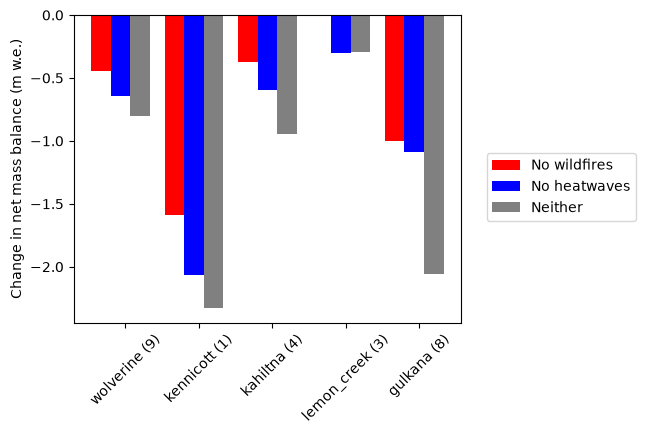

In [63]:
fig, ax = plt.subplots(figsize=(5, 4))
glaciers = []
for i, (rgiid, data) in enumerate(by_rgi.items()):
    n = len(data[list(data.keys())[0]])
    glaciers.append(f'{translate_names[rgiid]} ({n})' )

    for j, (color, (label, diffs)) in enumerate(zip(['r','b','gray'], data.items())):
        diff = np.nanmean(diffs)
        x = i*3 + j*0.8
        ax.bar(x, diff, facecolor=color)

ax.set_xticks(range(1, 16, 3))
ax.set_xticklabels(glaciers, rotation=45)

secondary = fig.add_axes([1.05, 0.05, 0.1, 0.8])
for label, color in zip(data, ['r','b','gray']):
    secondary.bar(0, np.nan, label=label, facecolor=color)
secondary.axis('off')
secondary.legend(loc='center')

ax.set_ylabel('Change in net mass balance (m w.e.)')
ax.axhline(0, c='k', linewidth=0.5)
plt.savefig(base_fp + '../Figs/by_glacier_sensitivity_without.png', dpi=300, bbox_inches='tight')
plt.show()

gulkana kp = -1.42 + 2.47 * elevation
lemon_creek kp = 2.71 + -1.05 * elevation
wolverine kp = 1.46 + 0.41 * elevation
kahiltna kp = 2.07 + 0.06 * elevation


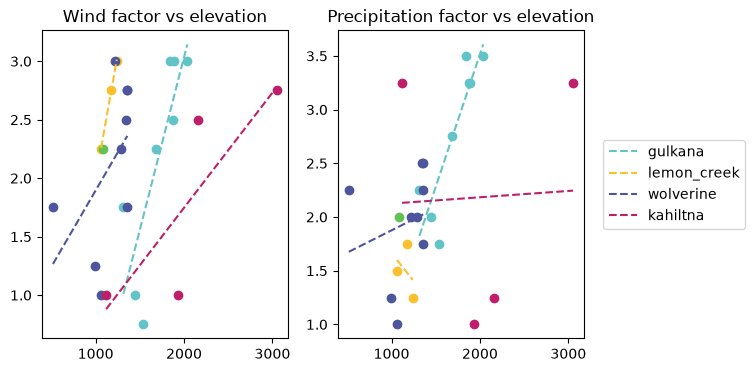

In [49]:
plot_maps = False 
plot_elevs = True

rgi = gpd.read_file(rgi_fp)

if plot_elevs:
    fig_elev, (ax_kw, ax_kp) = plt.subplots(1, 2, figsize=(7, 4))

for rgiid, color in zip(np.unique(rgiids), colors):
    idx_glac = np.array(rgiids) == rgiid
    sites_id = np.array(sites)[idx_glac]
    glacier = translate_names[rgiid]

    elevation = ds_base.sel(point=idx_glac).elev.values
    lats = ds_base.sel(point=idx_glac).lat.values
    lons = ds_base.sel(point=idx_glac).lon.values

    kps = np.array(configs['kp'])[idx_glac]
    kws = np.array(configs['wind_factor'])[idx_glac]
    
    shp = rgi.loc[rgi['RGIId'] == 'RGI60-' + rgiid]

    kw_cmap = mpl.colormaps['viridis_r']
    kp_cmap = mpl.colormaps['plasma_r']
    norm = mpl.colors.Normalize(vmin=0.75, vmax=3)

    minlon, minlat, maxlon, maxlat = shp.total_bounds
    ar = (maxlon - minlon) / (maxlat - minlat)

    figheight = 4
    figwidth = figheight * 1.2 * ar

    if plot_maps:
        fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(figwidth, figheight))
        
        for ax in [ax1, ax2]:
            shp.plot(ax=ax, facecolor='none', edgecolor='k', linewidth=1.0)

        for site, lat, lon, kp, kw in zip(sites_id, lats, lons, kps, kws):
            ax1.scatter(lon, lat, s=50, color=kw_cmap(norm(kw)))
            ax2.scatter(lon, lat, s=50, color=kp_cmap(norm(kp)))

            ax1.text(lon + 0.002, lat + 0.002, site)
            ax2.text(lon + 0.002, lat + 0.002, site)

        fig.suptitle(glacier)
        ax1.set_title(f'Wind factor')
        ax2.set_title(f'Precipitation factor')
        plt.show()

    if plot_elevs:
        ax_kp.scatter(elevation, kps, color=color)
        ax_kw.scatter(elevation, kws, color=color)

        if len(elevation) > 1:
            slope_kw, b_kw = np.polyfit(elevation, kws, 1)
            slope_kp, b_kp = np.polyfit(elevation, kps, 1)

            plot_elev = np.array([min(elevation), max(elevation)])
            ax_kw.plot(plot_elev, plot_elev*slope_kw + b_kw, linestyle='--', c=color)
            ax_kp.plot(plot_elev, plot_elev*slope_kp + b_kp, linestyle='--', c=color, label=glacier)

            print(glacier, f'kp = {b_kp:.2f} + {slope_kp * 1000:.2f} * elevation')

if plot_elevs:
    ax_kw.set_title('Wind factor vs elevation')
    ax_kp.set_title('Precipitation factor vs elevation')
    ax_kp.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.savefig(base_fp + '../Figs/params_vs_elevation.png', dpi=300, bbox_inches='tight')
plt.show()
    